In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.datasets as datasets

import matplotlib.pyplot as plt
from sklearn.decomposition import  PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from umap import  UMAP

In [2]:
import os, sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from src.dmsl import mean_shift_manifold_learning
from src.msde import mean_shift_density_enhancement

In [3]:
train_dataset = datasets.MNIST(root='./data', train=True, transform=None, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=None, download=True)

In [4]:
train_dataset.data = (train_dataset.data.float() / 255.0 - 0.1307) / 0.3081
test_dataset.data = (test_dataset.data.float() / 255.0 - 0.1307) / 0.3083

In [5]:
train_dataset.data.shape

torch.Size([60000, 28, 28])

In [6]:
def train(model, device, epochs=50):
    history = []
    knn = KNeighborsClassifier()

    model.to(device)
    data = train_dataset.data.to(device)
    data = data.unsqueeze(1)

    model.train()
    optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.99)
    criterion = nn.MSELoss()

    for epoch in range(epochs):
        optimizer.zero_grad()

        pred = model(data, epoch=epoch)
        loss = criterion(pred, data)

        loss.backward()
        optimizer.step()

        history.append(loss.item())
        if epoch % 10 == 0:
            print(f"Epoch {epoch:02d} | Full-Batch Loss: {loss.item():.4f}")

    model.eval()
    with torch.no_grad():
        emb = model.encoder(data, epoch=1)
        emb = emb.flatten(start_dim=1).cpu().numpy()

    knn.fit(emb, train_dataset.targets)
    return history, knn

In [7]:
def test(model, device, knn):
    model.to(device)
    data = test_dataset.data.to(device)
    data = data.unsqueeze(1)

    model.eval()
    with torch.no_grad():
        emb = model(data)
        emb = emb.flatten(start_dim=1).cpu().numpy()

    pred = knn.predict(emb)
    score = accuracy_score(test_dataset.targets, pred)
    return score

In [8]:
def visualize(model, device):
    model.to(device)

    train_data = train_dataset.data.to(device)
    train_data = train_data.unsqueeze(1)
    test_data = test_dataset.data.to(device)
    test_data = test_data.unsqueeze(1)

    model.eval()
    with torch.no_grad():
        train_emb = model(train_data)
        train_emb = train_emb.flatten(start_dim=1).cpu().numpy()

        test_emb = model(test_data)
        test_emb = test_emb.flatten(start_dim=1).cpu().numpy()

    pca = PCA(n_components=2)
    train_pca = pca.fit_transform(train_emb)
    test_pca = pca.transform(test_emb)

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1)
    plt.scatter(train_pca[:, 0], train_pca[:, 1], c=train_dataset.targets, cmap='tab10', alpha=0.6, s=5)
    plt.title('Train PCA')

    plt.subplot(1, 2, 2)
    sc1 = plt.scatter(test_pca[:, 0], test_pca[:, 1], c=test_dataset.targets, cmap='tab10', alpha=0.6, s=5)
    handles, labels = sc1.legend_elements()
    digit_names = [f"Digit {i}" for i in range(10)]
    plt.legend(handles, digit_names, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.title('Test PCA')

    plt.tight_layout()
    plt.show()

    umap = UMAP(n_components=2)
    train_umap = umap.fit_transform(train_emb)
    test_umap = umap.transform(test_emb)

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1)
    plt.scatter(train_umap[:, 0], train_umap[:, 1], c=train_dataset.targets, cmap='tab10', alpha=0.6, s=5)
    plt.title('Train UMAP')

    plt.subplot(1, 2, 2)
    sc2 = plt.scatter(test_umap[:, 0], test_umap[:, 1], c=test_dataset.targets, cmap='tab10', alpha=0.6, s=5)
    handles, labels = sc2.legend_elements()
    digit_names = [f"Digit {i}" for i in range(10)]
    plt.legend(handles, digit_names, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.title('Test UMAP')

# AutoEncoder without DMSL

In [9]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(8, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3),
        )

    def forward(self, x, epoch=0):
        x = self.encoder(x)
        return x

In [10]:
class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 64, kernel_size=3),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=3),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=3),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 8, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(8, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        x = self.decoder(x)
        return x

In [11]:
class AE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()
        
    def forward(self, x, epoch):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [12]:
autoencoder = AE().float()
history, knn = train(autoencoder, "mps", epochs=100)

Epoch 00 | Full-Batch Loss: 1.3119
Epoch 10 | Full-Batch Loss: 1.2718
Epoch 20 | Full-Batch Loss: 1.1807
Epoch 30 | Full-Batch Loss: 1.0890
Epoch 40 | Full-Batch Loss: 1.0343
Epoch 50 | Full-Batch Loss: 1.0118
Epoch 60 | Full-Batch Loss: 1.0041
Epoch 70 | Full-Batch Loss: 1.0016
Epoch 80 | Full-Batch Loss: 1.0007
Epoch 90 | Full-Batch Loss: 1.0004


In [13]:
score = test(autoencoder.encoder, "mps", knn)
print(f"Score: {score}")

Score: 0.9242


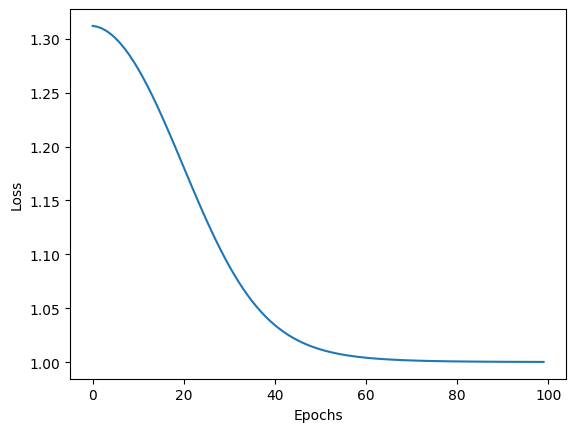

In [14]:
plt.plot(history)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

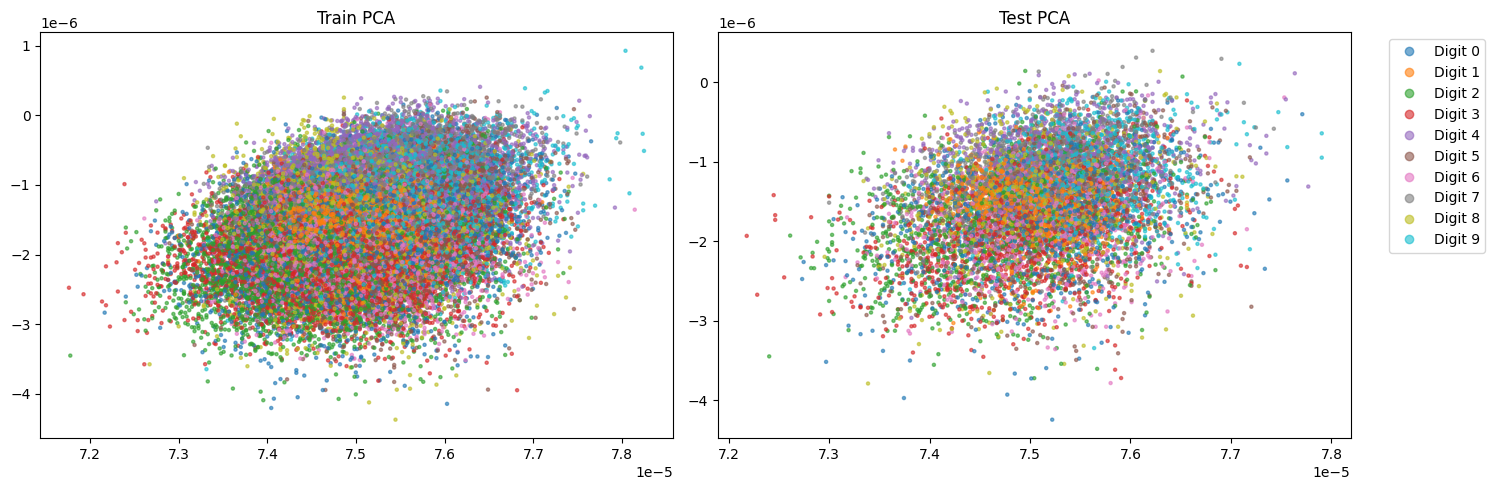

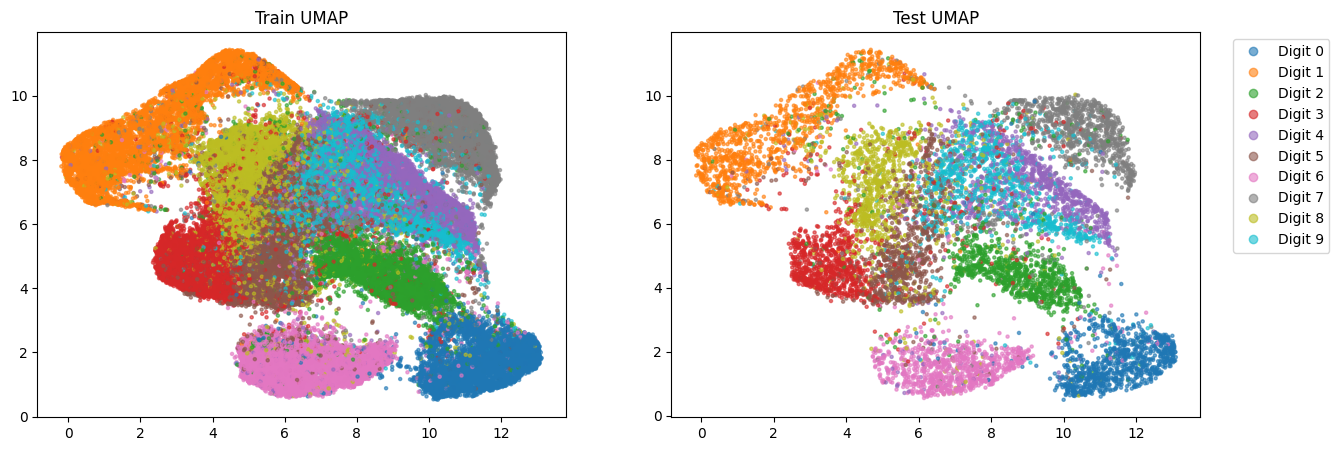

In [15]:
visualize(autoencoder, "mps")

# AutoEncoder with DMSL

In [20]:
class EncoderDMSL(Encoder):
    def __init__(self):
        super().__init__()
        with torch.no_grad():
            sample = torch.randn(1, 1, 28, 28)
            sample = self.encoder(sample)
            n_flatten = sample.flatten(start_dim=1).shape[1]

        self.linear = nn.Sequential(
            nn.Linear(n_flatten, n_flatten),
            nn.ReLU(),
        )
        self.weights = None

    def forward(self, x, epoch=1):
        x = self.encoder(x)
        x = x.flatten(start_dim=1)
        x = self.linear(x)

        raw = x.detach().cpu().numpy()
        if epoch == 0:
            shifted, self.weights, _, _ = mean_shift_manifold_learning(raw, max_iters_shift=500, k=50)
        else:
            shifted, _, _ = mean_shift_manifold_learning(raw, max_iters_shift=50, k=50, weights=self.weights)
        shift = torch.tensor(shifted - raw, dtype=torch.float, device=x.device, requires_grad=False)

        x = x + shift
        x = x.reshape(-1, 64, 1, 1)
        return x

In [21]:
class AEwithDMSL(AE):
    def __init__(self):
        super().__init__()
        self.encoder = EncoderDMSL()

    def forward(self, x, epoch=1):
        x = self.encoder(x, epoch)
        x = self.decoder(x)
        return x

In [22]:
ae_dmsl = AEwithDMSL().float()
history, knn = train(ae_dmsl, "mps", epochs=100)

DMSL shifts:  30%|███       | 151/500 [00:06<00:15, 23.09it/s]


Epoch 00 | Full-Batch Loss: 1.1875


DMSL shifts: 100%|██████████| 50/50 [00:01<00:00, 37.63it/s]


Epoch 10 | Full-Batch Loss: 1.1640


DMSL shifts: 100%|██████████| 50/50 [00:01<00:00, 37.22it/s]


...

DMSL shifts: 100%|██████████| 50/50 [00:01<00:00, 36.23it/s]


Epoch 80 | Full-Batch Loss: 1.0015


DMSL shifts: 100%|██████████| 50/50 [00:01<00:00, 36.07it/s]


Epoch 90 | Full-Batch Loss: 1.0008


DMSL shifts: 100%|██████████| 50/50 [00:01<00:00, 37.28it/s]


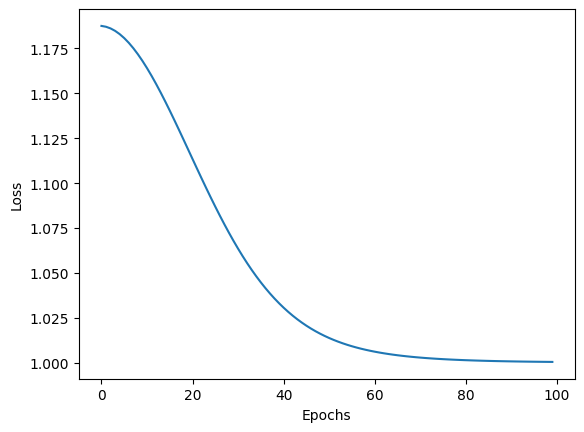

In [23]:
plt.plot(history)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

In [24]:
print(f"Score before DMSL: {test(ae_dmsl.encoder.encoder, "mps", knn)}")
print(f"Score after DMSL: {test(ae_dmsl.encoder, "mps", knn)}")

Score before DMSL: 0.107


DMSL shifts: 100%|██████████| 50/50 [00:00<00:00, 272.60it/s]


Score after DMSL: 0.247


### Before DMSL

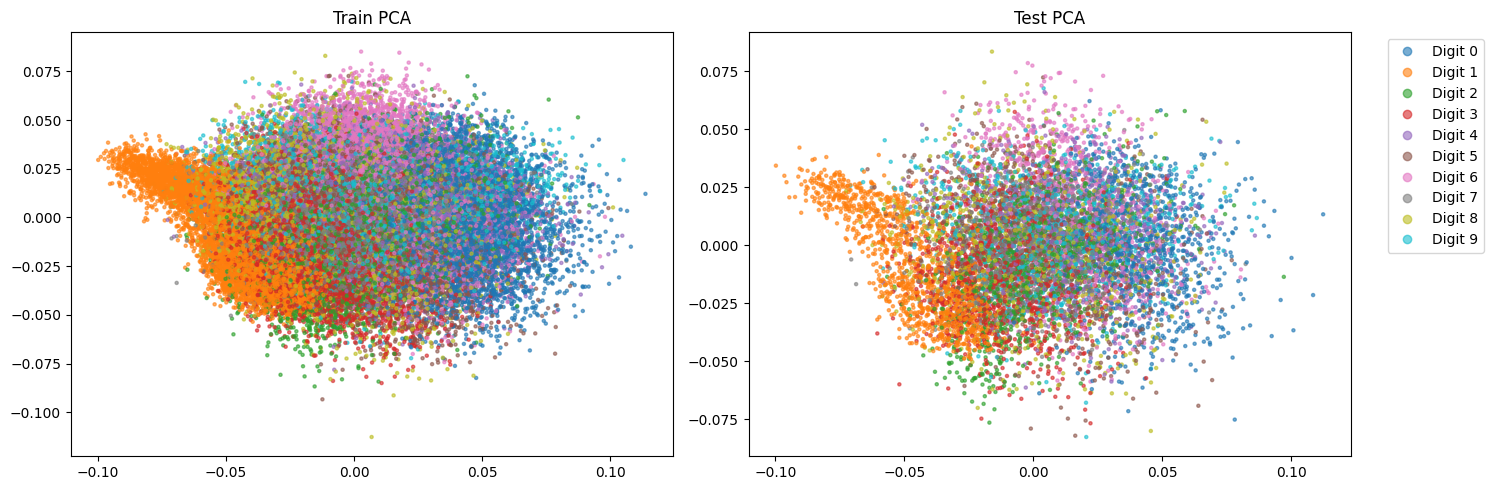

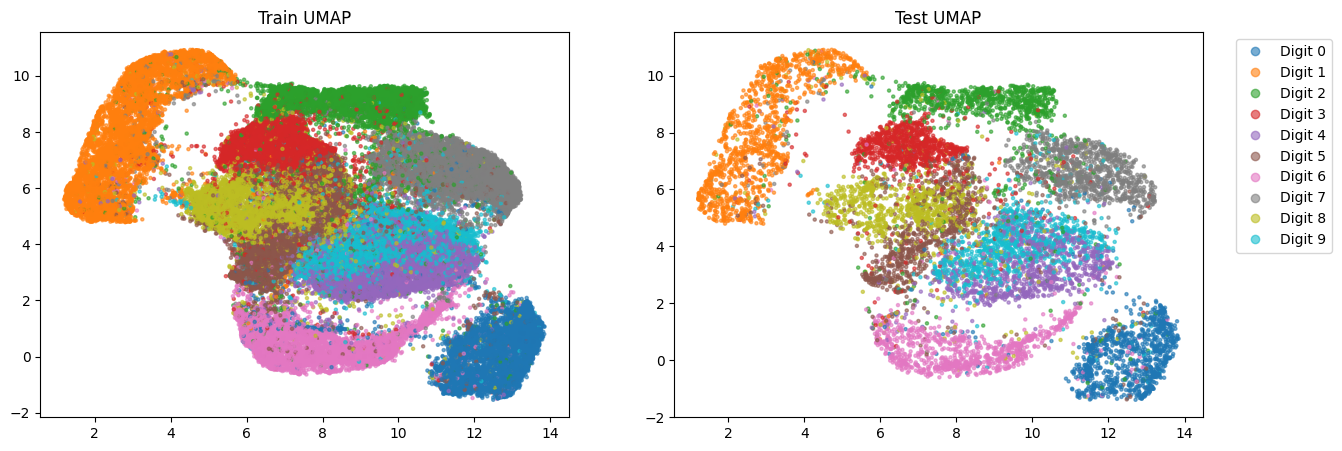

In [25]:
visualize(ae_dmsl.encoder.encoder, "mps")

### After DMSL

DMSL shifts: 100%|██████████| 50/50 [00:00<00:00, 274.09it/s]


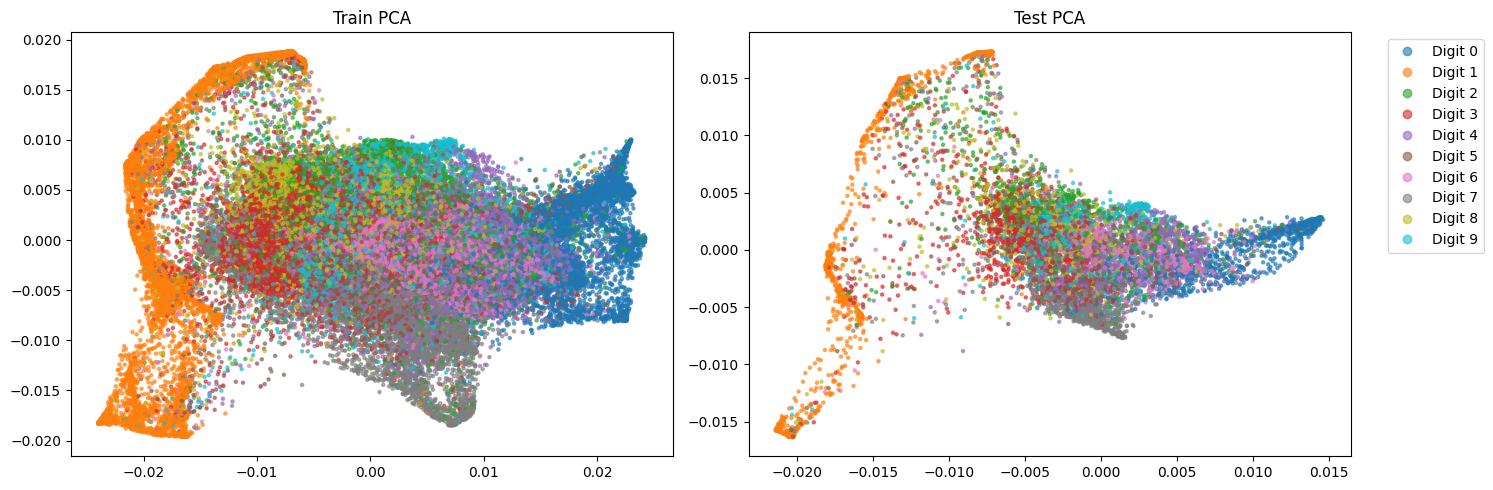

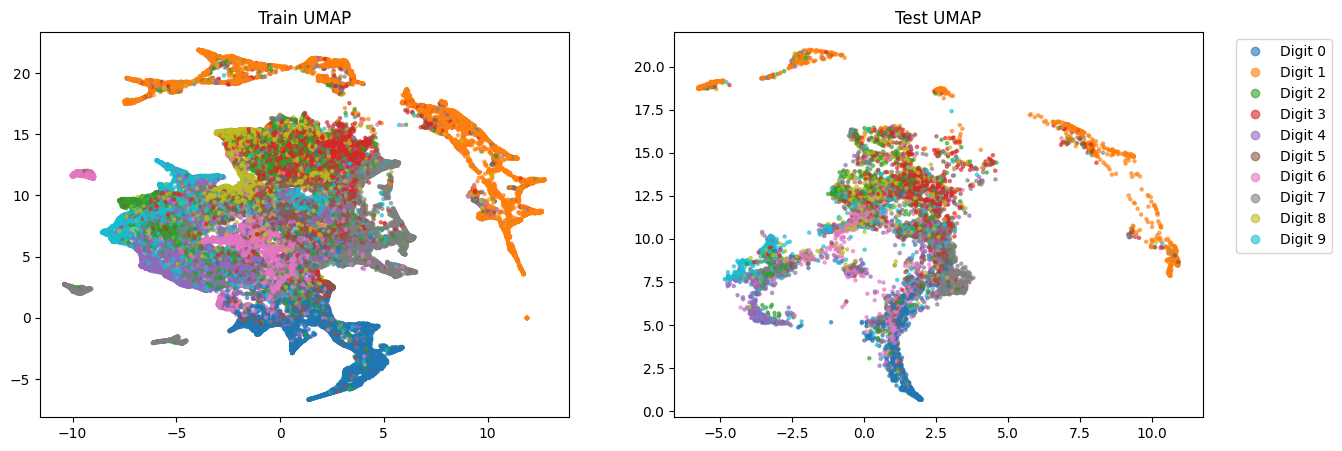

In [26]:
visualize(ae_dmsl.encoder, "mps")

# DMSL as Teacher

In [51]:
def distill_train(encoder, decoder, device, epochs=50):
    history = []
    knn = KNeighborsClassifier()

    encoder.to(device)
    decoder.to(device)
    data = train_dataset.data.to(device)
    data = data.unsqueeze(1)

    encoder.train()
    decoder.train()
    opt1 = optim.SGD(encoder.parameters(), lr=0.1, momentum=0.99)
    opt2 = optim.SGD(decoder.parameters(), lr=0.1, momentum=0.99)
    criterion = nn.MSELoss()

    for epoch in range(epochs):
        opt1.zero_grad()
        opt2.zero_grad()

        pred = encoder(data, epoch=epoch)
        raw = pred.flatten(start_dim=1).detach().cpu().numpy()

        if epoch == 0:
            shifted, weights, _, _ = mean_shift_manifold_learning(raw, max_iters_shift=500, k=50)
        else:
            shifted, _, _ =mean_shift_manifold_learning(raw, max_iters_shift=500, k=50, weights=weights)

        shifted = torch.tensor(shifted, dtype=torch.float, device=device).view(-1, 64, 1, 1)
        shift_loss = criterion(pred, shifted)

        pred = decoder(shifted)
        reconstruction_loss = criterion(pred, data)

        total_loss = reconstruction_loss + shift_loss * 1e2

        total_loss.backward()

        opt1.step()
        opt2.step()

        history.append(total_loss.item())
        if epoch % 1 == 0:
            print(f"Epoch {epoch:02d} | Encoder Loss: {shift_loss.item():.8f} | Decoder Loss: {reconstruction_loss.item():.8f}")

    encoder.eval()
    with torch.no_grad():
        emb = encoder(data)
        emb = emb.flatten(start_dim=1).cpu().numpy()

    knn.fit(emb, train_dataset.targets)
    return history, knn

In [52]:
encoder = Encoder().float()
decoder = Decoder().float()
history, knn = distill_train(encoder, decoder, "mps", epochs=25)

DMSL shifts:  63%|██████▎   | 313/500 [00:09<00:05, 32.94it/s]


Epoch 00 | Encoder Loss: 0.00009048 | Decoder Loss: 1.26577842


DMSL shifts:  59%|█████▊    | 293/500 [00:08<00:05, 35.59it/s]


Epoch 01 | Encoder Loss: 0.00008152 | Decoder Loss: 1.25876153


DMSL shifts:  52%|█████▏    | 259/500 [00:07<00:07, 33.20it/s]


...

Epoch 22 | Encoder Loss: 0.00000231 | Decoder Loss: 1.00075936


DMSL shifts:  13%|█▎        | 64/500 [00:01<00:13, 33.30it/s]


Epoch 23 | Encoder Loss: 0.00000216 | Decoder Loss: 1.00056207


DMSL shifts:  13%|█▎        | 63/500 [00:01<00:12, 33.70it/s]


Epoch 24 | Encoder Loss: 0.00000201 | Decoder Loss: 1.00042617


In [53]:
score = test(encoder, "mps", knn)
print(f"Score: {score}")

Score: 0.781


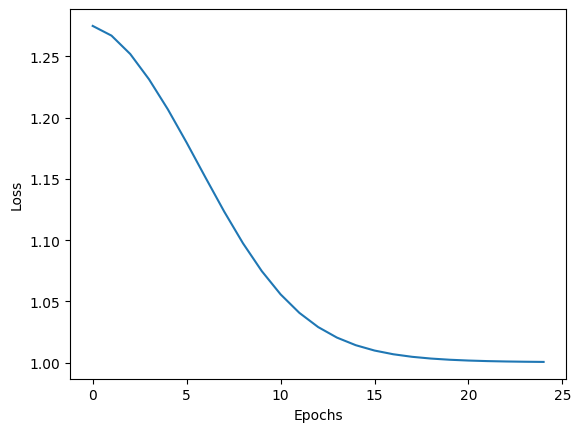

In [54]:
plt.plot(history)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

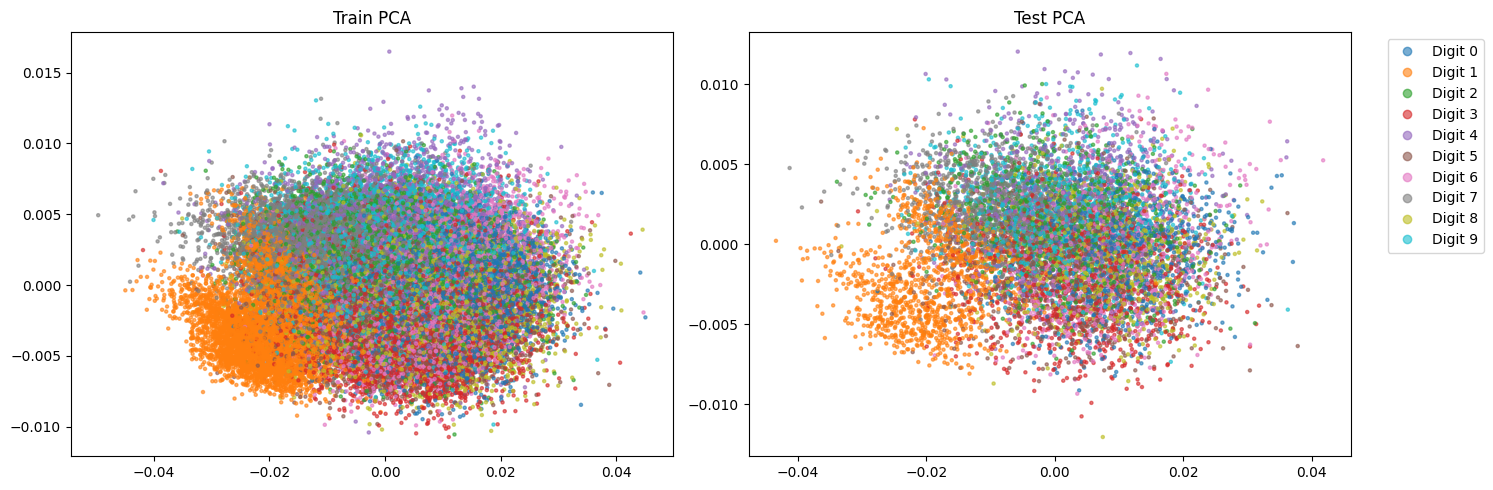

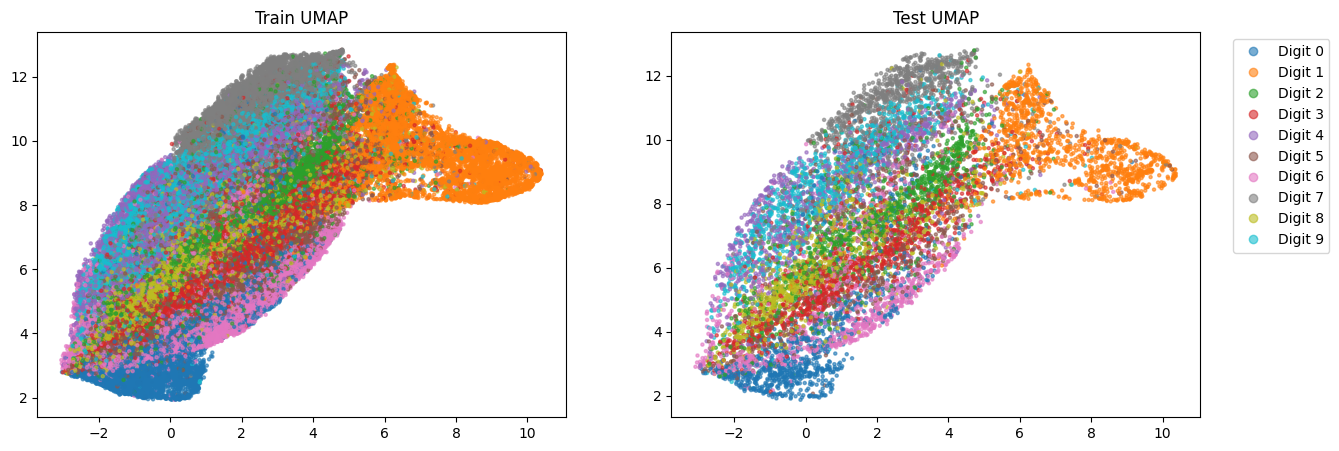

In [55]:
visualize(encoder, "mps")